# Симуляционный анализ мощности статистических тестов

В этом задании мы с вами разберем универсальный способ изучать кривые мощности статистических тестов (а значит и искать необходимое число наблюдений для заданного MDE при дизайне экспериментов). Сделаем мы это на примере парных тестов из предыдущего задания.

Если вы посмотрите на занятие по выводу MDE для классических тестов, то там мы с вами выводили уравнение зависимости между мощностью, MDE, числом наблюдений и уровнем значимости. Если попробовать применить такой подход к нашим трем обсуждаемым тестам, мы окажемся в терновых кустах: для t-теста вывод точной формулы связан с выводом нецентрированного т-распределения и его квантилями, для теста Wilcoxon-а и перестановочного теста -- с жуткой комбинаторикой (особенно если мы возьмем в качестве эффекта среднее отклонение, а тесты измеряют медианные). И такая ситуация нередка -- для огромного числа способов искать противоречия в H0 вывести формулу мощности очень тяжелая задача. 

Поэтому мы снова **вооружаемся методом Монте-Карло и проводим симуляционное тестирование**. 

Напомним основные термины:

**Мощность** - вероятность того, что тест обнаружит нарушение нулевой гипотезы, если оно есть. $P(H_1 \mid H_1)$
    - Для сложных альтернатив (например, когда мы ищем любое другое ма-ожидание распределения, кроме того, что в $H_0$) бычно это "нарушение" конкретизируют: например, указывают, насколько отличается сравниваемый параметр (это назывывают **effect size / размер эффекта**)

**Кривая мощности** - график мощности как функции от различных параметров. Обычно рассматривают зависимость от числа наблюдений или от размера эффекта.


## Идея симуляционного тестирования

Поскольку мощность -- характеристика теста, которая описывает его *поведение на всех возможных выборках* (в рамках множества, заданного зафиксированной альтернативой), мы можем **получить её оценку**:
- зафисируем альтернативу (обычно это выбор **effect size**)
- возьмем B выборок, соответствующих нашей зафиксированной альтернативе 
  - (то есть на которых $H_0$ должна быть отвергнута) 
- проведём на каждой тест
- получим долю тех, где тест отклонит нулевую гипотезу

то есть букально получим выборочную оценку вероятности, $\widehat{P(H_1 \mid H_1)}$.

*Пример:* возьмем B=10_000 выборок размера n=100 из распределения $N(0+0.5; 1)$, где наш effect size $\delta = 0.5$. Для каждой из B выборок проведем тест, который мы исследуем, получим B вердиктов: p-value больше или меньше $\alpha$, $H_0$ не отвергается / отвергается. Посчитаем число выборок, где $H_0$ отверглась; допустим, их оказалось 7560. Поделим на B и получим долю отвержения $H_0$ в экспериментах: 0.756. То есть, наша Монте-Карло оценка мощности для теста при n=100 и $\delta = 0.5$ оказалась равна 0.756. То есть, в такой доле выборок с такой силой эффекта (и такими предпосылками в постановке задачи) наш тест отклоняет нулевую гипотезу в 75.6% случаев.

### Доверительный интервал для Монте-Карло оценки

Наша оценка мощности фактически является биномиальной случайной величиной, которую мы делим на B: $\widehat{P(H_1 \mid H_1)} \sim Bin(1 - \beta; B)$, где истинная вероятность успеха равна истинной мощности, и мы проводим B независимых экспериментов. Поэтому, чтобы получить не только точечную оценку мощности, но и её доверительный интервал, можно воспользоваться доверительным интервалом для доли. Вам предлагается использовать CI по методу Clopper-Pearson, и, к сожалению, просто поверить в него: сейчас он слишком сложный, чтобы вникать в него по-честному.

### Кривая мощности

Такое симуляционное тестирование можно независимо проводить для разных значений параметров: перебирать размер выборки, effect size, или оба по сетке (все возможные пары из заранее заданного списка). Это позволит получить вам 1-мерную, 2-мерную или даже 3-мерную (если добавить $\alpha$) поверхность как график функции мощности, и проанализировать, как она изменяется. Впрочем, помните, чем больше размерностей в графике, тем тяжелее его читать.

# Задание

Вам необходимо:

1) дописать код для анализа кривой мощности трех парных тестов. 
   - Архитектура кода и основная обвязка уже написаны за вас, вам нужно только дописать смысловые части.
2) провести анализ полученных результатов и сделать выводы о мощностях тестов.


Ориентируйтесь на инфраструктуру кода (её менять запрещено), докстринги, комментарии, а также пример запуска ниже.

Архитектура мини-проекта и необходимые доработки:

```markdown
project
│   task.ipynb
|       - Этот ноутбук, вводная и точка входа / запуска
|   interfaces.py
|       - Здесь обозначены протоколы. Классы проекта ожидают объекты, которые подчиняются указанным протоколам / интерфейсам.
|   tests.py
|       - Статистические тесты, мощность которых мы будем измерять
|       - *Здесь необходимо имплементировать парные стат-тесты. Можно пользоваться библиотечными версиями, но permutation test напишите сами.*
|   samplers.py
|       - Генераторы случайных выборок согласно переданным характеристикам распределений при верных альтернативах
│   core.py
|       - Симуляционное ядро проекта, делает всю тяжелую работу с переданными тестами и генераторами
|       - *Здесь необходимо имплементировать процедуру симуляционного анализа. Сделайте это эффективно при помощи numpy и параллелизации.*
|   vizualization.py
|       - Здесь содержатся функции для красивого вывода результатов и отрисовки графиков симуляционного тестирования.
|       - *Здесь необходимо реализовать отрисовку графиков, опираясь на результаты тестирования.*
```


Про протоколы и структурную типизацию как краеугольный камень архитектуры можно почитать здесь; отличная вводная статья: https://realpython.com/python-protocol/

Как и всегда, LLM можно пользоваться только для сборки графиков по описанию деталей визуализации; в случае использования прикладывайте промпт и рефлексию о том, как и что пришлось менять.

## 1. Допишите код проекта
как указано выше. Добейтесь успешного запуска кода в следующей ячейке.

Running power analysis...

H1 distribution : Normal(δ=0.5, σ=1.0)
alpha=0.05, simulations=3000
     n            paired_ttest    wilcoxon_signed_rank  Paired permutation test
-------------------------------------------------------------------------------
    10     0.296 [0.280,0.313]     0.290 [0.274,0.307]     0.293 [0.276,0.309]
    20     0.579 [0.561,0.597]     0.541 [0.523,0.559]     0.574 [0.556,0.592]
    30     0.759 [0.743,0.774]     0.730 [0.714,0.746]     0.748 [0.732,0.763]
    50     0.931 [0.922,0.940]     0.920 [0.909,0.929]     0.925 [0.915,0.934]
    75     0.990 [0.985,0.993]     0.986 [0.981,0.990]     0.987 [0.982,0.991]
   100     0.999 [0.998,1.000]     0.998 [0.995,0.999]     0.999 [0.997,1.000]

H1 distribution : LogNormal(μ=0.3, σ=0.6)
alpha=0.05, simulations=3000
     n            paired_ttest    wilcoxon_signed_rank  Paired permutation test
-------------------------------------------------------------------------------
    10     0.052 [0.044,0.061]     0.05

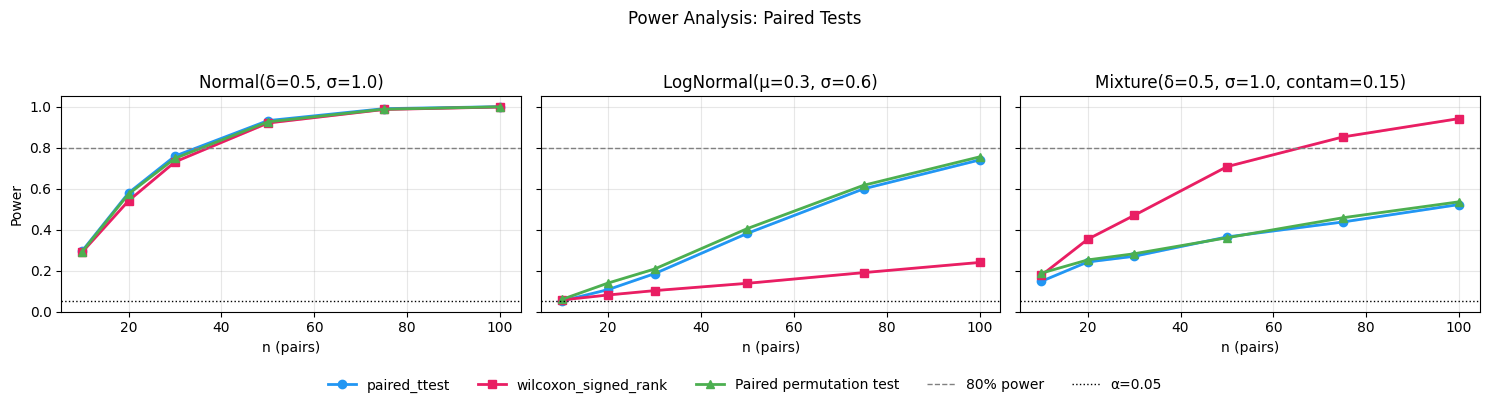

In [1]:
from tests import paired_ttest, wilcoxon_signed_rank, PermutationTest
from samplers import NormalShiftSampler, LognormalShiftSampler, MixtureSampler
from core import ComparisonSpec, run_comparison
from vizualization import print_comparison, plot_comparison

import matplotlib.pyplot as plt 


SAMPLE_SIZES = [10, 20, 30, 50, 75, 100]
N_SIM = 3000

tests = [
    paired_ttest,
    wilcoxon_signed_rank,
    PermutationTest(n_permutations=499),
]

samplers = [
    NormalShiftSampler(effect_size=0.5, sigma=1.0),
    LognormalShiftSampler(mu=0.3, sigma=0.6),
    MixtureSampler(effect_size=0.5, sigma=1.0, contamination=0.15),
]


spec = ComparisonSpec(
    tests=tests,
    samplers=samplers,
    sample_sizes=SAMPLE_SIZES,
    alpha=0.05,
    n_simulations=N_SIM,
    seed=42,
)

print("Running power analysis...")
results = run_comparison(spec)
print_comparison(spec, results)

plot_comparison(
    spec, results,
    ci_level=0.05,
    save_path="./temp.png"
)
plt.show()



## 2. Проанализируйте результаты тестирования и ответьте на вопросы.


*Подсказка: вам может быть полезно вывести распределения, генерируемые по этим H1*.

**2.1** Что происходит с мощностями тестов при росте числа наблюдений в случае нормального распределения разниц с cohen's d в 0.5? Как это объяснить свойствами тестов?

**2.2** Что происходит с общей и относительной мощностью тестов при альтернативном распределении по `LognormalShiftSampler`? В каком порядке по мощности они располагаются? Какой тест проседает, и как это связано с тем, к каким отклонениям он чувствителен? Что можно сказать о робастности т-теста к нарушению предпосылки о нормальности?

**2.3** Что происходит с общей и относительной мощностью тестов при альтернативном распределении по `MixtureSampler`? В каком порядке по мощности они располагаются? Почему, как их реакция обусловлена алгоритмом проведения этих тестов?

**2.4** Придумайте и имплементируйте такой генератор для H1, что для него перестановочный тест будет мощнее, чем два оставшихся. Продемонстрируйте результат и опишите, почему он добивается цели. 
- *Подсказка: посмотрите, к чему чувствительны все три теста, а что ломает их чувствительность к отличиям, и придумайте распределение, которое использует эти факты.*
- *Можно вдохновиться MixtureSampler и поэкспериментировать с его параметрами.*



---

2.1 Чем больше n – тем больше мощность теста. Ну тут просто при росте n у нас будет уменьшаться стандартная ошибка, а учитывая что настоящий эффект cohen's d фиксирован и не исчезает, то тестам становится легче отличить ситуацию с ненулевой средней разницей от H_0 (ну или тут можно было просто сказать про состоятельность тестов, которая говорит о том что если нулевая гипотеща на самом деле ложна, то при росте размера выборки тест будет отвергать ее все чаще, в пределе доведя веряятность до 1)

2.2 Ну тут в отличие от нормального распределение мощности заметно ниже сами по себе, так еще и скорость роста мощности от размера выборки растет медленнее. тест Вилкоксона так вообще просел относительно ттеста, в отличие от ситуации при нормальном распределении. Порядок мощностей такой: ttest > permutation > wilcoxon. добротно проседает именно тест Вилкоксона. Ну тут возможно ттест и перестановочный тест показывают себя хорошо, потому чот они смотрят именно на среднее и видят эти редкие боьшие значения, а вот вилкоксон использует ранги, поэтому большую часть сигнала теряет: численная огромность почти не используется, а если эффект сидит в хвосте распределения и сильно меняет среднее – он это не увидит. ТТест оказался в целом довольно робастным, но скорее так произошло только в этом конкретном сценарии, тк у нас хвосты сильнее меняют среднее, чем разброс.

2.3 тут правила игры меняются и на первое место с отрывом выходит мощность вилкоксона. дальше идут permutation > ttest. Относительно нормального здесь конечно мощности поменьше, но вилкоксон не сильно отстает при n=100. ttest и permutation скатились: возможно как раз потому, что здесь у нас нет особого сигнала в среднем, но есть очень длинные хвосты, раздувающие дисперсию. А вот Вилкоксон устойчив за счет рангов

2.4 

Ну тут была идея просто сделать тяжелые хвосты, чтобы ттест был не так хорош, и сильно сдвинуть одну из частей, чтобы использование рангов вместо значений теряло информацию

In [20]:
from typing import Optional
import numpy as np
import seaborn as sns

In [7]:
class RarePositiveBigEffectSampler:
    def __init__(
        self,
        true_delta: float = 0.5,
        p_positive: float = 0.30,
        negative_mean: float = -0.5,
        negative_sigma: float = 0.15,
        positive_sigma: float = 0.35,
        rng: Optional[np.random.Generator] = None,
    ):
        self.true_delta = true_delta
        self.p_positive = p_positive
        self.negative_mean = negative_mean
        self.negative_sigma = negative_sigma
        self.positive_sigma = positive_sigma
        self.rng = rng if rng is not None else np.random.default_rng()

        self.positive_mean = (
            self.true_delta - (1 - self.p_positive) * self.negative_mean
        ) / self.p_positive

        self.__name__ = (
            f"RarePositiveBigEffect("
            f"true_delta={true_delta}, p_pos={p_positive}, "
            f"neg={negative_mean}, pos={self.positive_mean:.2f})"
        )

    def __call__(self, n_pairs: int) -> np.ndarray:
        is_positive = self.rng.random(n_pairs) < self.p_positive
        differences = np.empty(n_pairs)

        differences[~is_positive] = self.rng.normal(
            loc=self.negative_mean,
            scale=self.negative_sigma,
            size=(~is_positive).sum(),
        )

        differences[is_positive] = self.rng.normal(
            loc=self.positive_mean,
            scale=self.positive_sigma,
            size=is_positive.sum(),
        )

        return differences



H1 distribution : RarePositiveBigEffect(true_delta=0.5, p_pos=0.4, neg=-0.2, pos=1.55)
alpha=0.05, simulations=3000
     n            paired_ttest    wilcoxon_signed_rank  Paired permutation test
-------------------------------------------------------------------------------
    10     0.071 [0.062,0.081]     0.044 [0.037,0.052]     0.073 [0.064,0.083]
    50     0.639 [0.622,0.657]     0.070 [0.061,0.080]     0.641 [0.623,0.658]
    75     0.847 [0.834,0.860]     0.075 [0.066,0.085]     0.847 [0.834,0.860]
   100     0.934 [0.925,0.943]     0.075 [0.066,0.085]     0.938 [0.929,0.946]
   150     0.989 [0.984,0.992]     0.073 [0.064,0.083]     0.995 [0.992,0.997]
   200     0.998 [0.996,0.999]     0.065 [0.056,0.074]     1.000 [0.999,1.000]


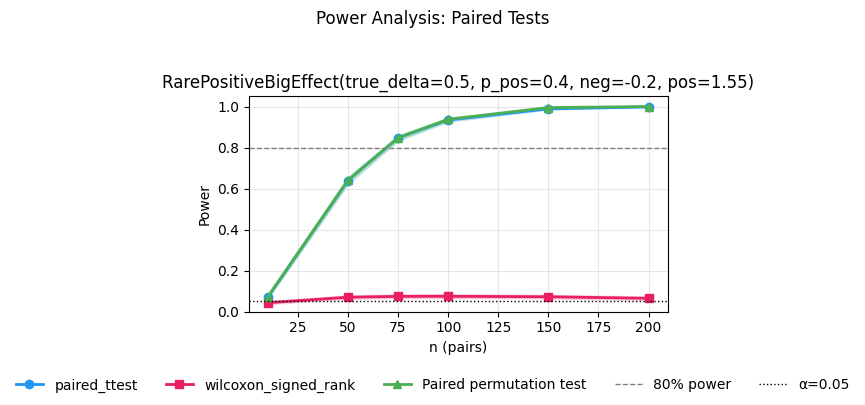

In [17]:

SAMPLE_SIZES = [10, 50, 75, 100, 150, 200]

sampler = RarePositiveBigEffectSampler(
        true_delta=0.5,
        p_positive=0.4,
        negative_mean=-0.2,
        negative_sigma=0.05,
        positive_sigma=2,
    )

samplers = [
    sampler
]


spec = ComparisonSpec(
    tests=tests,
    samplers=samplers,
    sample_sizes=SAMPLE_SIZES,
    alpha=0.05,
    n_simulations=N_SIM,
    seed=42,
)

results = run_comparison(spec)
print_comparison(spec, results)

plot_comparison(spec, results, ci_level=0.95)
plt.show()


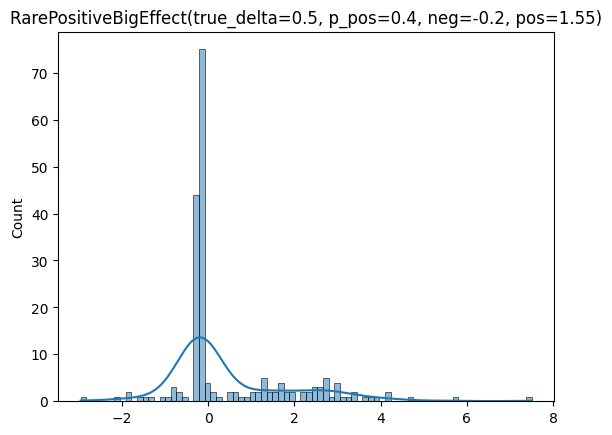

In [21]:

data = sampler(200)

sns.histplot(data, bins=80, kde=True)
plt.title(sampler.__name__)
plt.show()
